<a href="https://colab.research.google.com/github/Serragem/Circuito-Quantico-Ciclico-1/blob/main/SeparadoresDeFeixe5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulação computacional quântica de uma partícula submetida a uma sequência de separadores de feixe

"You never understand things. You just get used to them." (John von Neumann)

# QISKIT: Carregamento


In [2]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc

import qiskit
qiskit.__version__

'2.3.1'

In [3]:
# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city

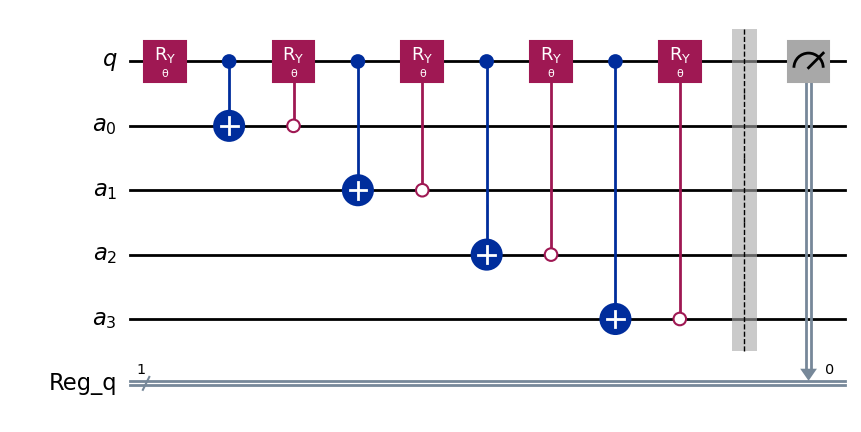

In [4]:
from qiskit.circuit import Parameter

q = QuantumRegister(1, "q")
a = QuantumRegister(4, "a")
reg_q = ClassicalRegister(1, "Reg_q")
reg_a = ClassicalRegister(5, "Reg_a")
qc = QuantumCircuit(q,a,reg_q)#,reg_a)

theta = Parameter('θ')

qc.ry(theta, q[0])
for k in range(4):
  qc.cx(q[0],a[k])
  qc.cry(theta, a[k],q[0], ctrl_state=0)

qc.barrier()
qc.measure(q,reg_q)
#qc.measure(a,reg_a)

qc.draw('mpl')

# Simulação

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np # Import numpy for pi

simulator = AerSimulator()

# Assign a numerical value to theta
# We'll use pi/2 as an example. You can change this value.
theta_value = np.pi / 4
qc_bound = qc.assign_parameters({theta: theta_value})

# Transpile the circuit for the simulator
transpiled_qc_bound = transpile(qc_bound, simulator)

# 3. Run the Circuit
shots = 2**(12)
job = simulator.run(transpiled_qc_bound, shots=shots)
result = job.result()
print(result)
classical_register_name = transpiled_qc_bound.cregs[0].name

counts = result.results[0].data.counts # Corrected to access results attribute

print(counts.keys())

probabilidades = [counts.get('0x0', 0) / shots, counts.get('0x1', 0) / shots]

probabilidades_dict = {'0': probabilidades[0], '1': probabilidades[1]}

probabilidades_dict

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='d18c4152-3c0d-48f0-819d-2ac01dcd284e', success=True, results=[ExperimentResult(shots=4096, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 1870, '0x1': 2226}), header={'creg_sizes': [['Reg_q', 1]], 'global_phase': 0.0, 'memory_slots': 1, 'n_qubits': 5, 'name': 'circuit-48', 'qreg_sizes': [['q', 1], ['a', 4]], 'metadata': {}}, status=DONE, seed_simulator=2339803095, metadata={'time_taken': 0.00333474, 'num_bind_params': 1, 'parallel_state_update': 2, 'parallel_shots': 1, 'required_memory_mb': 1, 'input_qubit_map': [[4, 4], [3, 3], [2, 2], [1, 1], [0, 0]], 'method': 'statevector', 'device': 'CPU', 'num_qubits': 5, 'sample_measure_time': 0.00091239, 'active_input_qubits': [0, 1, 2, 3, 4], 'num_clbits': 1, 'remapped_qubits': False, 'runtime_parameter_bind': False, 'max_memory_mb': 12975, 'noise': 'ideal', 'measure_sampling': True, 'batched_shots_optimization': False, 'fusion': {'applied': False, 'ma

{'0': 0.45654296875, '1': 0.54345703125}

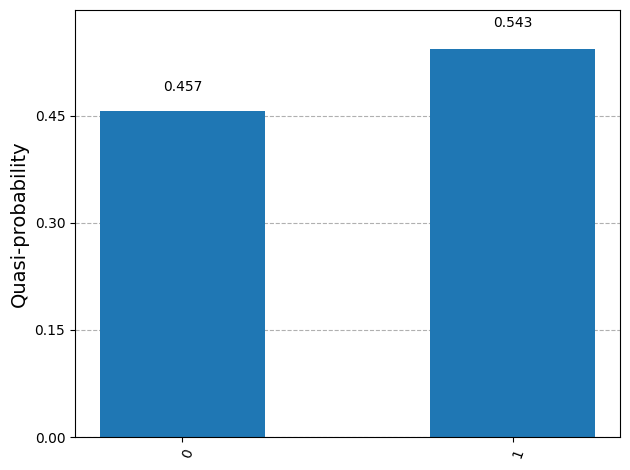

In [6]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Plot the histogram of the counts
plot_histogram(probabilidades_dict)#, title='Probabilidades na base computacional')

In [7]:
print(f"Previsão teórica: {1855/2**12}. Simulação: {np.cos(np.pi/8)**10}")

Previsão teórica: 0.452880859375. Simulação: 0.4530576408488159
